## Summarization in Chatbot

The Goal is to take teh summary of the messages in the running conversation and then pass it to LLMs.
This allows us to have the context of the chat saved. 

In [1]:
import os
from dotenv import load_dotenv
load_dotenv()

os.environ['LANGCHAIN_API_KEY'] = os.getenv('LANGSMITH_API_KEY')
os.environ["LANGCHAIN_TRACING_V2"] = "true" # Enable LangSmith tracing
os.environ['LANGSMITH_PROJECT'] = 'LangGraphTraining' 

In [2]:
from langchain_aws import ChatBedrockConverse

model = ChatBedrockConverse(model= "us.anthropic.claude-sonnet-4-6",)

[transformers] PyTorch was not found. Models won't be available and only tokenizers, configuration and file/data utilities can be used.


In [3]:
from pprint import pprint
from langgraph.graph import MessagesState
from langchain_core.messages import SystemMessage, HumanMessage, AIMessage, RemoveMessage
from langgraph.graph import START, END
from typing_extensions import Literal



c:\Data\Codes\AgenticAITraining\Lanchain_LangGraph\.venv\Lib\site-packages\langgraph\cache\base\__init__.py:8: LangChainPendingDeprecationWarning: The default value of `allowed_objects` will change in a future version. Pass an explicit value (e.g., allowed_objects='messages' or allowed_objects='core') to suppress this warning.
  from langgraph.checkpoint.serde.jsonplus import JsonPlusSerializer


We will be using messagesState, and incldude a custom key - Summary 

In [4]:
class State(MessagesState):
    summary: str


In [5]:
# Node for the conversation
def conversation(state: State) -> State:
    summary = state.get('summary', '')
    if summary:
        system_message = f'Summary of earlier conversaion: {summary}'
        messages = [SystemMessage(content = system_message)] + state['messages']
    else: 
        messages = state['messages']

    response = model.invoke(messages)
    return {'messages': response}

In [6]:
# Node for summarization 
def summarize(state: State):
    summary = state.get('summary', '')
    if summary:
        summary_message = (
                f"This is summary of the conversation to date: {summary}\n\n"
                "Extend the summary by taking into account the new messages above:"
            )
    else:
        summary_message = "Summarize the conversation above:"
    messages = state['messages'] + [HumanMessage(content=summary_message)]
    response = model.invoke(messages)

    # Deleting all the messages, but keeping the last 2
    delete_messages = [RemoveMessage(id=m.id) for m in state['messages'][:-2]]
    return {
        'summary': response.content,
        'messages': delete_messages
    }

In [7]:
# Condition for getting the summary
def should_continue(state: State):
    messages = state['messages']
    if len(messages) >= 5:
        return 'summarize'
    else:
        return END

Adding memory, using the checkpointers.

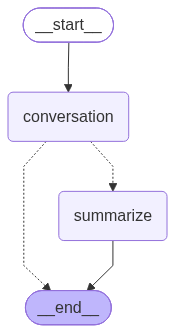

In [21]:
from langgraph.checkpoint.memory import MemorySaver
from langgraph.graph import StateGraph, START, END

workflow = StateGraph(State)
workflow.add_node('conversation', conversation)
workflow.add_node('summarize', summarize)

workflow.add_edge(START, 'conversation')
workflow.add_conditional_edges(
    'conversation',
    should_continue,
    {'summarize': 'summarize', END: END}
)
workflow.add_edge('summarize', END)

memory= MemorySaver()
graph = workflow.compile(checkpointer=memory)
graph

In [22]:
config = {'configurable': {'thread_id': '1'}}

In [23]:
# Starting the conversation

input_message = HumanMessage(content = 'Hi, I am Ayush, from India.')
output = graph.invoke({'messages': [input_message]}, config=config)

for m in output['messages'][-1:]:
    m.pretty_print()

input_message = HumanMessage(content = 'What is my name?')
output = graph.invoke({'messages':[input_message]}, config=config)

for m in output['messages'][-1:]:
    m.pretty_print()

input_message = HumanMessage(content="I like the Agentic AI")
output = graph.invoke({"messages": [input_message]}, config) 
for m in output['messages'][-1:]:
    m.pretty_print()

================================== Ai Message ==================================

Hi Ayush! 👋

Welcome! It's great to meet you. How are you doing today?

Is there something I can help you with, or would you just like to chat? 😊
================================== Ai Message ==================================

Your name is **Ayush**! You mentioned it at the start of our conversation. 😊

Is there anything I can help you with today?
================================== Ai Message ==================================

That's great, Ayush! 😊

**Agentic AI** is indeed a fascinating and rapidly growing area! 

Here are some key aspects of Agentic AI:

- **Autonomous Decision Making** - AI agents can make decisions and take actions on their own
- **Goal-Oriented** - They work towards achieving specific goals
- **Multi-Step Tasks** - They can break down complex tasks into smaller steps
- **Tool Usage** - They can use various tools like web search, code execution, etc.
- **Self-Improvement** - Some a

In [28]:
graph_state = graph.get_state(config)
pprint(graph_state.values)
pprint(graph_state)

{'messages': [HumanMessage(content='I like the Agentic AI', additional_kwargs={}, response_metadata={}, id='511c6418-56f3-4279-aa7e-cfffdcebe652'),
              AIMessage(content="That's great, Ayush! 😊\n\n**Agentic AI** is indeed a fascinating and rapidly growing area! \n\nHere are some key aspects of Agentic AI:\n\n- **Autonomous Decision Making** - AI agents can make decisions and take actions on their own\n- **Goal-Oriented** - They work towards achieving specific goals\n- **Multi-Step Tasks** - They can break down complex tasks into smaller steps\n- **Tool Usage** - They can use various tools like web search, code execution, etc.\n- **Self-Improvement** - Some agents can learn and adapt from their experiences\n\nSome popular **Agentic AI frameworks** include:\n- **LangChain**\n- **AutoGPT**\n- **CrewAI**\n- **Microsoft AutoGen**\n- **LlamaIndex**\n\nAgentic AI is being widely used in areas like:\n- **Automation**\n- **Research**\n- **Customer Service**\n- **Software Development**

In [29]:
input_message = HumanMessage(content="I like langgraph, isn't it balance reliability with control?") 
output = graph.invoke({"messages": [input_message]}, config) 
for m in output['messages'][-1:]:
    m.pretty_print()

================================== Ai Message ==================================

Yes, absolutely Ayush! 🎯

**LangGraph** is an excellent choice! It indeed strikes a great balance between **reliability** and **control**!

## Why LangGraph Balances Reliability with Control:

### 🔒 Control Features:
- **Graph-based Architecture** - You have full control over the flow of your agent
- **State Management** - Explicitly define and manage state at each step
- **Conditional Edges** - Control which path the agent takes based on conditions
- **Human-in-the-Loop** - Ability to pause and get human approval at any point

### ✅ Reliability Features:
- **Structured Workflows** - Predictable and consistent behavior
- **Error Handling** - Better error management compared to simple chains
- **Checkpointing** - Save and resume agent state
- **Persistence** - Maintain state across multiple interactions

### 🌟 Key Advantages of LangGraph:
- **Cyclical Graphs** - Unlike simple chains, it supports loops and 

In [30]:
graph.get_state(config).values.get("summary","")

"Here's a summary of our conversation:\n\n1. **Introduction** - You introduced yourself as **Ayush** from **India**.\n\n2. **Name Recall** - You asked me if I remembered your name, and I correctly identified it as **Ayush**.\n\n3. **Interest in Agentic AI** - You mentioned that you like **Agentic AI**, and I provided a detailed overview of Agentic AI, including its key aspects, popular frameworks, and use cases.\n\nIn short, you are **Ayush** from **India**, and you have a keen interest in **Agentic AI**! 😊"

In [31]:
graph.get_state(config).values.get("messages","")

[HumanMessage(content='I like the Agentic AI', additional_kwargs={}, response_metadata={}, id='511c6418-56f3-4279-aa7e-cfffdcebe652'),
 AIMessage(content="That's great, Ayush! 😊\n\n**Agentic AI** is indeed a fascinating and rapidly growing area! \n\nHere are some key aspects of Agentic AI:\n\n- **Autonomous Decision Making** - AI agents can make decisions and take actions on their own\n- **Goal-Oriented** - They work towards achieving specific goals\n- **Multi-Step Tasks** - They can break down complex tasks into smaller steps\n- **Tool Usage** - They can use various tools like web search, code execution, etc.\n- **Self-Improvement** - Some agents can learn and adapt from their experiences\n\nSome popular **Agentic AI frameworks** include:\n- **LangChain**\n- **AutoGPT**\n- **CrewAI**\n- **Microsoft AutoGen**\n- **LlamaIndex**\n\nAgentic AI is being widely used in areas like:\n- **Automation**\n- **Research**\n- **Customer Service**\n- **Software Development**\n- **Data Analysis**\n\nA

#### SQLite 
Uisng SQLite DB for storing the checkpointers

In [8]:
import sqlite3
# conn = sqlite3.connect(':memory:', check_same_thread=False)  # Use an in-memory database for testing, allow multiple threads to access it

db_path = 'state_db/example.db'

if not os.path.exists(db_path):
    os.makedirs(os.path.dirname(db_path), exist_ok=True)
conn = sqlite3.connect(db_path, check_same_thread=False)  

In [9]:
from langgraph.checkpoint.sqlite import SqliteSaver
memory = SqliteSaver(conn)

In [10]:
# Creating the same graph
workflow = StateGraph(State)
workflow.add_node('conversation', conversation)
workflow.add_node('summarize', summarize)

workflow.add_edge(START, 'conversation')
workflow.add_conditional_edges(
    'conversation',
    should_continue,
    {'summarize': 'summarize', END: END}
)
workflow.add_edge('summarize', END)
graph = workflow.compile(checkpointer=memory)
graph

NameError: name 'StateGraph' is not defined

In [ ]:
input_message = HumanMessage(content = 'Hi, I am Ayush, from India.')
output = graph.invoke({'messages': [input_message]}, config=config)

for m in output['messages'][-1:]:
    m.pretty_print()

input_message = HumanMessage(content = 'What is my name?')
output = graph.invoke({'messages':[input_message]}, config=config)

for m in output['messages'][-1:]:
    m.pretty_print()

input_message = HumanMessage(content="I like the Agentic AI")
output = graph.invoke({"messages": [input_message]}, config) 
for m in output['messages'][-1:]:
    m.pretty_print()

================================== Ai Message ==================================

Hi Ayush! 👋

Welcome! It's great to meet you. How are you doing today?

Is there something I can help you with, or would you just like to have a conversation? Feel free to ask me anything! 😊
================================== Ai Message ==================================

Your name is **Ayush**! You mentioned it at the beginning of our conversation. 😊

Is there anything else I can help you with?
================================== Ai Message ==================================

That's great, Ayush! 😊

**Agentic AI** is indeed a fascinating and rapidly evolving field! 

Here are some key aspects of Agentic AI:

- **Autonomous Decision Making** - AI agents can make decisions and take actions on their own to achieve goals
- **Task Planning** - They can break down complex tasks into smaller steps
- **Tool Use** - Agentic AI can use various tools like web search, code execution, etc.
- **Multi-Agent Systems** - 

In [ ]:
graph_state = graph.get_state(config)
graph_state

StateSnapshot(values={'messages': [HumanMessage(content='I like the Agentic AI', additional_kwargs={}, response_metadata={}, id='a15a8793-fad4-4a19-8094-2f909d7c5986'), AIMessage(content="That's great, Ayush! 😊\n\n**Agentic AI** is indeed a fascinating and rapidly evolving field! \n\nHere are some key aspects of Agentic AI:\n\n- **Autonomous Decision Making** - AI agents can make decisions and take actions on their own to achieve goals\n- **Task Planning** - They can break down complex tasks into smaller steps\n- **Tool Use** - Agentic AI can use various tools like web search, code execution, etc.\n- **Multi-Agent Systems** - Multiple AI agents can work together to solve complex problems\n- **Self-Improvement** - Some agentic systems can learn and improve from their experiences\n\nSome popular examples include:\n- **AutoGPT**\n- **LangChain Agents**\n- **CrewAI**\n- **Microsoft AutoGen**\n\nIt is becoming very popular in India as well, with many developers and companies exploring its p

In [ ]:
graph.get_state(config).values.get("summary","")

"Here's a summary of our conversation:\n\n1. **Introduction** - You introduced yourself as **Ayush** from **India**.\n\n2. **Name Recall** - You asked me if I remembered your name, and I correctly identified it as **Ayush**.\n\n3. **Interest in Agentic AI** - You mentioned that you like **Agentic AI**, and I provided a detailed overview of the topic, including:\n   - Key aspects of Agentic AI\n   - Popular tools/frameworks\n   - Its applications in India\n\nIt's been a brief but interesting conversation! 😊 Is there anything else you'd like to discuss, **Ayush**?"